In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl

import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Roboto"]
mpl.rcParams["figure.dpi"] = 100

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 12,
    "axes.titleweight": "regular",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

In [4]:
def evolve(x0, y0, f, N=1, crit=0):
  traj = np.zeros((N+1, 8))
  traj[0] = np.array([*x0, *y0])
  x = x0
  y = y0

  for t in range(1, N+1):
    if t % 25 == 0:
        # print(f"LD at {t}: {x[0]*x[3]-x[1]*x[2] + y[0]*y[3]-y[1]*y[2]:.8f}")
        # print(f"LD at {t}: {(x[0]+y[0])*(x[3]+y[3])-(x[1]+y[1])*(x[2]+y[2]):.8f}")
        
        c=0.5
        s = 0.1
        R0 = 1-s/2
        w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
        w_bar = np.dot(x, w) + np.dot(y, w)
        Ds = (w[0]*w[3]*(x[0]+y[0])*(x[3]+y[3]) - w[1]*w[2]*(x[1]+y[1])*(x[2]+y[2])) / w_bar**2
        # print(f"Expected LD: {(1-c)*Ds:.8f}\n")
        
    if (t+1)%250 == 0:
      um1 = x.sum()
      um2 = y.sum()
      r_11 = 0.010000
      r_22 = 0.336667
      r_12 = 0.173333
      
      reff = r_11 * um1**2 + 2*r_12*um1*um2 + r_22 * um2**2
      print(f"reff at {t+1}: {reff} <? {(0.1 / 1.1)}")
        
    if t == crit:
      # amt = 0.5
      # y = amt * x.copy()
      # x = (1-amt)* x
      amt = 0.001
      y[3]+=amt
      freq_total = x.sum() + y.sum()
      x /= freq_total
      y /= freq_total
      
    #   if t % 100 == 0:
    #       print(x, y)
    x, y = f(x, y)
    traj[t] = np.array([*x, *y])

  return traj

def plot_traj(traj, N_gen):
    generations = np.arange(traj.shape[0])
    labels = [r"$x_1$", r"$x_2$", r"$x_3$", r"$x_4$", r"$y_1$", r"$y_2$", r"$y_3$", r"$y_4$"]
    colors = ['navy', 'forestgreen', 'purple', 'crimson']

    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    for i in range(4):
        plt.plot(generations, traj[:, i], label=labels[i], color=colors[i], alpha=0.7)
    for i in range(4):
        plt.plot(generations, traj[:, i+4], label=labels[i+4], color=colors[i], alpha=0.7, ls='--')

    plt.ylim(-0.05, 1.05)
    plt.xlim(0, N_gen)
    plt.ylabel('Frequency')
    plt.xlabel('Generation')
    plt.title(r'Invasion') # for $r_{12}=r_{22}=0.05$ with Invasion of $M_2$ into $M_1$
    plt.legend()
    plt.show()

def evolve_traj(f, x_init=np.zeros(4), y_init=np.zeros(4), N_gen=2000):
  traj = evolve(x_init, y_init, f, N_gen)
  plot_traj(traj, N_gen)
  return traj

reff at 250: 0.13765376723491726 <? 0.09090909090909091
reff at 500: 0.13048321513597738 <? 0.09090909090909091
reff at 750: 0.12541749404425112 <? 0.09090909090909091
reff at 1000: 0.113204267721191 <? 0.09090909090909091
reff at 1250: 0.03558179964639126 <? 0.09090909090909091
reff at 1500: 0.03558179671018611 <? 0.09090909090909091
reff at 1750: 0.03558179671018611 <? 0.09090909090909091
reff at 2000: 0.03558179671018611 <? 0.09090909090909091


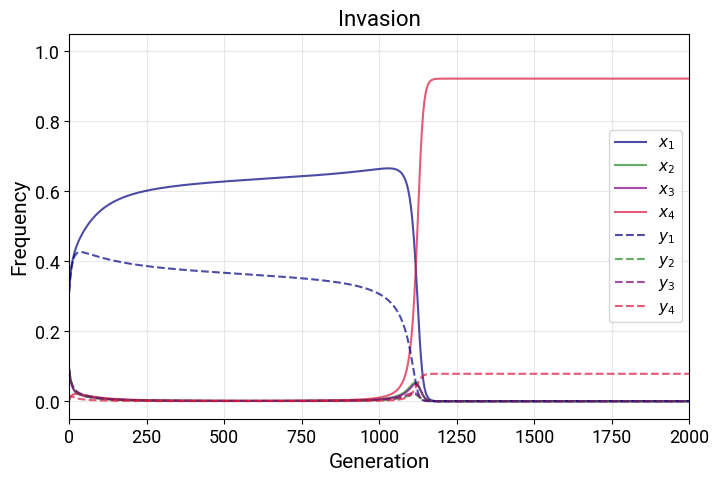

[1.19284175e-47 3.74950313e-48 3.93137835e-48 9.21688236e-01
 3.28394389e-49 8.22347505e-49 6.40472290e-49 7.83117636e-02]


In [5]:
def f(x, y):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w) + np.dot(y, w)
  
  r_11 = 0.010000
  r_22 = 0.336667
  r_12 = 0.173333 # 0.5*(r_1 + r_2)
  r = 0.1000

  # 0: ab, 1: Ab, 2: aB, 3: AB
  # x: modifier m, y: modifier M
  x_prime = np.zeros(4)
  y_prime = np.zeros(4)
  
  cross_loss_indices = [
    [1, 2, 3, 3],  # abm with AbM, abM, ABM
    [0, 3, 2, 2],  # Abm with abM, ABM, aBM
    [3, 0, 1, 1],  # aBm with ABM, abM, AbM
    [2, 1, 0, 0],  # ABm with aBM, AbM, abM
  ]

  # x[i] * y[j]
  cross_gain_pairs = [
    [(1,2), (1,0), (2,1), (2, 0)], # ab
    [(0,3), (0,1), (3,0), (3,1)], # Ab
    [(3,0), (3,2), (0,3), (0,2)], # aB
    [(2,1), (2,3), (1,2), (1,3)] # AB
  ]

  x = x*w / w_bar
  y = y*w / w_bar
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (x[i1] * (y[2] + y[3]) - x[i2] * (y[0] + y[1]))
    
    # Recombination between the B and M loci
    # reco_bm = r * (sum([x[i] * y[j] for j in range(4) if j != i]) - sum([y[i] * x[j] for j in range(4) if j != i]))
    reco_bm = r * (x[i] * (y.sum() - y[i]) - y[i] * (x.sum() - x[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*x[i]*y[il] - 2*x[il]*y[i] + x[i]*y[3-i] + x[ia]*y[3-ia] - x[3-i]*y[i] - x[3-ia]*y[ia])
    
    x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # loss = -0.5 * r_h * [x[i] * y[cross_loss_indices[i]]].sum()
    # gain = 0.5 * r_h * sum(x[j]*y[k] for (j,k) in cross_gain_pairs[i])
    # gain_brute = cross_recombination_gain(x, y, r_h)

    # x_prime[i] = x[i] + within + loss + gain
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (y[i1] * (x[2] + x[3]) - y[i2] * (x[0] + x[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (y[i] * (x.sum() - x[i]) - x[i] * (y.sum() - y[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*y[i]*x[il] - 2*y[il]*x[i] + y[i]*x[3-i] + y[ia]*x[3-ia] - y[3-i]*x[i] - y[3-ia]*x[ia])
    
    y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
    
    # # Old code without r
    # sgn = -1 if i in [0,3] else 1
    # within = sgn * r_2 * (y[0]*y[3] - y[1]*y[2])
    # loss = -0.5 * r_h * y[i] * x[cross_loss_indices[i]].sum()
    # gain = 0.5 * r_h * sum(y[j]*x[k] for (j,k) in cross_gain_pairs[i])

    # y_prime[i] = y[i] + within + loss + gain
  
  total = x_prime.sum() + y_prime.sum()
  x_prime /= total
  y_prime /= total
  return x_prime, y_prime

# Initialization
x1 = 0.6
x4 = 0.05
x2 = (1 - x1 - x4) / 2
x3 = x2

total = 0.0
y_r = np.random.dirichlet(np.ones(4)) * total


x_init = np.array([x1, x2, x3, x4])
y_init = np.array(y_r)
y_init = np.array([x1, x2, x3, x4])

x_init = np.array([0.314474,	0.090263,	0.090263,	0.005000])
y_init = np.array([0.314474,	0.090263,	0.090263,	0.005000])

# Normalization
freq_total = x_init.sum() + y_init.sum()
x_init /= freq_total
y_init /= freq_total



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})

traj = evolve_traj(f, x_init, y_init, 2000)
print(traj[-1])

Final state:
[0.66365902 0.00590115 0.00494633 0.01030666 0.30656478 0.00312662
 0.00408144 0.00141401]


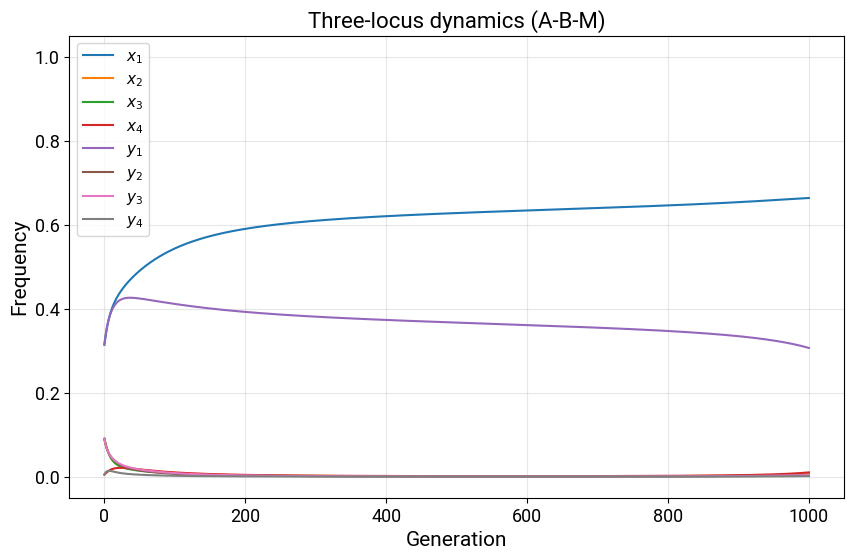

In [182]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Dynamics function (your code, unchanged except final renorm)
# ------------------------------------------------------------
def f(x, y):

    s = 0.1
    R0 = 1 - s/2
    w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])

    r_11 = 0.01
    r_22 = 0.336667
    r_12 = 0.173333
    r = 0.1

    w_bar = np.dot(x,w) + np.dot(y,w)

    x = x*w / w_bar
    y = y*w / w_bar

    x_prime = np.zeros(4)
    y_prime = np.zeros(4)

    for i in range(4):

        sgn_wtn = 1 if i in [0,3] else -1
        reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

        il = (i + 2) % 4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if i in [2,3] else 1
        reco_ab_between = sgn_btwn * r_12 * (x[i1]*(y[2]+y[3]) - x[i2]*(y[0]+y[1]))

        reco_bm = r * (x[i]*(y.sum()-y[i]) - y[i]*(x.sum()-x[i]))

        ia = i - 1 if i%2==1 else i + 1
        reco_double = r*r_12*(2*x[i]*y[il] - 2*x[il]*y[i]
                              + x[i]*y[3-i] + x[ia]*y[3-ia]
                              - x[3-i]*y[i] - x[3-ia]*y[ia])

        x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    for i in range(4):

        sgn_wtn = 1 if i in [0,3] else -1
        reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

        il = (i + 2) % 4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if i in [2,3] else 1
        reco_ab_between = sgn_btwn * r_12 * (y[i1]*(x[2]+x[3]) - y[i2]*(x[0]+x[1]))

        reco_bm = r * (y[i]*(x.sum()-x[i]) - x[i]*(y.sum()-y[i]))

        ia = i - 1 if i%2==1 else i + 1
        reco_double = r*r_12*(2*y[i]*x[il] - 2*y[il]*x[i]
                              + y[i]*x[3-i] + y[ia]*x[3-ia]
                              - y[3-i]*x[i] - y[3-ia]*x[ia])

        y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    total = x_prime.sum() + y_prime.sum()
    x_prime /= total
    y_prime /= total

    return x_prime, y_prime


# ------------------------------------------------------------
# Trajectory evolution
# ------------------------------------------------------------
def evolve_traj(f, x0, y0, steps):

    traj = np.zeros((steps+1,8))
    traj[0,:4] = x0
    traj[0,4:] = y0

    x = x0.copy()
    y = y0.copy()

    for t in range(steps):

        x,y = f(x,y)

        traj[t+1,:4] = x
        traj[t+1,4:] = y

    return traj


# ------------------------------------------------------------
# Initial condition (your example)
# ------------------------------------------------------------
x_init = np.array([0.314474,0.090263,0.090263,0.005000])
y_init = np.array([0.314474,0.090263,0.090263,0.005000])

total = x_init.sum() + y_init.sum()
x_init /= total
y_init /= total


# ------------------------------------------------------------
# Run simulation
# ------------------------------------------------------------
steps = 1000
traj = evolve_traj(f,x_init,y_init,steps)

print("Final state:")
print(traj[-1])


# ------------------------------------------------------------
# Derived quantities
# ------------------------------------------------------------
p = traj[:,:4] + traj[:,4:]

A = p[:,1] + p[:,3]
B = p[:,2] + p[:,3]
M = traj[:,4:].sum(axis=1)

time = np.arange(steps+1)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(10,6))

plt.plot(time,traj[:,0],label=r"$x_1$")
plt.plot(time,traj[:,1],label=r"$x_2$")
plt.plot(time,traj[:,2],label=r"$x_3$")
plt.plot(time,traj[:,3],label=r"$x_4$")
plt.plot(time,traj[:,4],label=r"$y_1$")
plt.plot(time,traj[:,5],label=r"$y_2$")
plt.plot(time,traj[:,6],label=r"$y_3$")
plt.plot(time,traj[:,7],label=r"$y_4$")
# plt.plot(time,traj[:, 1],label="Ab")
# plt.plot(time,p[:,2],label="aB")
# plt.plot(time,p[:,3],label="AB")

# plt.plot(time,A,"--",label="A allele")
# plt.plot(time,B,"--",label="B allele")
# plt.plot(time,M,":",label="Modifier M")

plt.xlabel("Generation")
plt.ylabel("Frequency")
plt.ylim([-0.05, 1.05])
plt.title("Three-locus dynamics (A-B-M)")
plt.legend()
plt.show()

In [ ]:
x1 = 0.5
x4 = 0.1
x2 = (1 - x1 - x4) / 2
x3 = x2
x_init = np.array([x1-0.001, x2, x3, x4])
y_init = np.array([0.0, 0.001, 0.0, 0.0])

/Users/chasevanamburg/miniforge3/envs/mf/lib/python3.13/site-packages/matplotlib/patches.py:3436: RuntimeWarning: invalid value encountered in scalar divide
  cos_t, sin_t = head_length / head_dist, head_width / head_dist


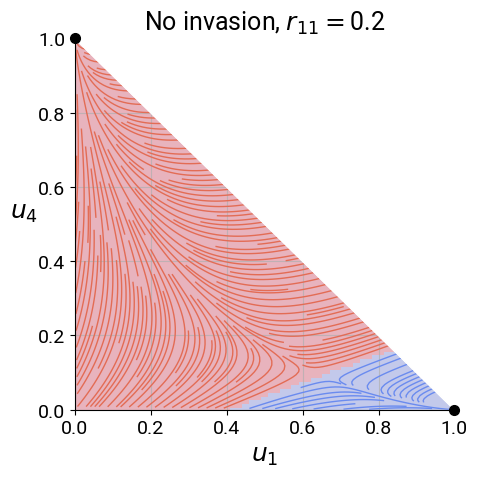

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.patches import Polygon

y_total = 0.0
r_1 = 0.2
r_2 = 0.4
rM = 0.1

def f(x, y):
  s = 0.1
  R0 = 1-s/2
  w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])
  w_bar = np.dot(x, w) + np.dot(y, w)
  
  r_11 = r_1
  r_22 = r_2
  r_12 = r_2 # 0.5*(r_1 + r_2)
  r = rM

  # 0: ab, 1: Ab, 2: aB, 3: AB
  # x: modifier , y: modifier M
  x_prime = np.zeros(4)
  y_prime = np.zeros(4)

  x = x*w / w_bar
  y = y*w / w_bar
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (x[i1] * (y[2] + y[3]) - x[i2] * (y[0] + y[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (x[i] * (y.sum() - y[i]) - y[i] * (x.sum() - x[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*x[i]*y[il] - 2*x[il]*y[i] + x[i]*y[3-i] + x[ia]*y[3-ia] - x[3-i]*y[i] - x[3-ia]*y[ia])
    
    x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
  
  for i in range(4):
    # Recombination within same modifier allele
    sgn_wtn = 1 if i in [0,3] else -1
    reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

    # Recombination between the A and B loci
    il = (i + 2) % 4
    i1 = min(i, il)
    i2 = max(i, il)
    sgn_btwn = -1 if i in [2, 3] else 1
    reco_ab_between = sgn_btwn * r_12 * (y[i1] * (x[2] + x[3]) - y[i2] * (x[0] + x[1]))
    
    # Recombination between the B and M loci
    reco_bm = r * (y[i] * (x.sum() - x[i]) - x[i] * (y.sum() - y[i]))
    
    # Recombination and accounting between both pairs of adjacent loci
    ia = i - 1 if i%2==1 else i + 1
    reco_double = r * r_12 * (2*y[i]*x[il] - 2*y[il]*x[i] + y[i]*x[3-i] + y[ia]*x[3-ia] - y[3-i]*x[i] - y[3-ia]*x[ia])
    
    y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double
  
  return x_prime, y_prime

def evolve(x0, f, N=200):
  traj = np.zeros((N+1, 8))
  
  total = y_total
  y0 = np.random.dirichlet(np.ones(4)) * total
  freq_total = x0.sum() + y0.sum()
  x = x0 / freq_total
  y = y0 / freq_total
  
  traj[0] = np.array([*x0, *y0])

  for t in range(1, N+1):
    x, y = f(x, y)
    traj[t] = np.array([*x, *y])

  return traj

init_points = [ ]
grid = np.linspace(0.02, 0.98, 100)
for x1 in grid:
    for x4 in grid:
        if x1+x4 <= 1:
            x2 = (1-x1-x4)/2
            x3 = x2
            x = np.array([x1, x2, x3, x4])
            init_points.append(x)
final_points = np.array([evolve(x, f)[-1] for x in init_points])
kmeans = KMeans(n_clusters=2, n_init=10, random_state=0).fit(np.array([final_points[:, 0] + final_points[:, 4], final_points[:, 3] + final_points[:, 7]]).T)
centers = kmeans.cluster_centers_


n = 100
x1_flat = np.linspace(0.0, 1.0, n)
x4_flat = x1_flat.copy()
x1s, x4s = np.meshgrid(x1_flat, x4_flat)
mask = (x1s + x4s) <= 1.0
x1s_masked = np.ma.masked_where(~mask, x1s)
x4s_masked = np.ma.masked_where(~mask, x4s)

delta_x1 = np.zeros_like(x1s)
delta_x4 = np.zeros_like(x4s)

basin_labels = np.zeros_like(x1s, dtype=int)

for i in range(n):
    for j in range(n):
        x1, x4 = x1s[i, j], x4s[i, j]
        x2 = (1 - x1 - x4) / 2
        x3 = x2
        x = np.array([x1, x2, x3, x4])
        y = np.random.dirichlet(np.ones(4)) * y_total
        freq_total = x.sum() + y.sum()
        x_prime, y_prime = f(x/freq_total, y/freq_total)
        for k in range(3):
          x_prime, y_prime = f(x_prime, y_prime)
        delta_x1[i, j] = x_prime[0] + y_prime[0] - (x[0] + y[0])
        delta_x4[i, j] = x_prime[3] + y_prime[3] - (x[3] + y[3])
        
        x_f = evolve(x, f)[-1]
        basin_labels[i, j] = kmeans.predict([[x_f[0] + x_f[4], x_f[3] + x_f[7]]])[0]


fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel(r"$u_1$")
ax.set_ylabel(r"$u_4$", rotation=0, labelpad=10)
ax.grid(True, alpha=0.7)

basin_labels = 1 - basin_labels
ax.pcolormesh(x1s, x4s, basin_labels, cmap="coolwarm", shading="auto", alpha=0.3, vmin=0, vmax=1)
color_map = [plt.cm.coolwarm(0.15), plt.cm.coolwarm(0.85)]

for label, color in enumerate(color_map):
    delta_x1_masked = np.ma.masked_where(basin_labels != label, delta_x1)
    delta_x4_masked = np.ma.masked_where(basin_labels != label, delta_x4)
    # delta_x1_masked = np.ma.masked_where(~mask, delta_x1_masked)
    # delta_x4_masked = np.ma.masked_where(~mask, delta_x4_masked)

    strm = ax.streamplot(x1s, x4s, delta_x1_masked, delta_x4_masked, color=color, density=3, linewidth=1, arrowsize=0, integration_direction="forward")
    triangle = Polygon(
        [(0, 0), (1, 0), (0, 1)],
        closed=True,
        transform=ax.transData
    )
    strm.lines.set_clip_path(triangle)
    strm.arrows.set_clip_path(triangle)
    ax.fill(
        [0, 1, 1],
        [1, 0, 1],
        color="white",
        zorder=3
    )

ax.plot(centers[:, 0], centers[:, 1], 'ko', markersize=7, label="Equilibria", clip_on=False, zorder=10) # centers[1:, 0], centers[1:, 1]
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
title1 = (
    r"Invasion, $r_{11}=$"
    f"{r_1} "
    r", $r_{12}=r_{22}=$"
    f"{r_2} "
)
title2 = r"No invasion, $r_{11}=$" + str(r_1)
title = title1 if y_total > 0 else title2 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Roboto"],
    "font.size": 14,
    "axes.titleweight": "regular",
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 11,
    "figure.titlesize": 16
})
plt.title(title); plt.tight_layout(); plt.show() # , $r_{12}=r_{22}=0.4$


In [79]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Evolution function ----
def f_param(x, y, r_11, r_12, r_22, r):

    s = 0.1
    R0 = 1 - s/2
    w = np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])

    w_bar = np.dot(x, w) + np.dot(y, w)

    x = x*w / w_bar
    y = y*w / w_bar

    x_prime = np.zeros(4)
    y_prime = np.zeros(4)

    for i in range(4):

        # within modifier recombination
        sgn_wtn = 1 if i in [0,3] else -1
        reco_ab_wtn = sgn_wtn * r_11 * (x[0]*x[3] - x[1]*x[2])

        il = (i + 2) % 4
        i1 = min(i, il)
        i2 = max(i, il)

        sgn_btwn = -1 if i in [2,3] else 1
        reco_ab_between = sgn_btwn * r_12 * (x[i1]*(y[2]+y[3]) - x[i2]*(y[0]+y[1]))

        # B-M recombination
        reco_bm = r * (x[i]*(y.sum()-y[i]) - y[i]*(x.sum()-x[i]))

        # double recombination bookkeeping
        ia = i-1 if i%2==1 else i+1
        reco_double = r*r_12 * (
            2*x[i]*y[il] - 2*x[il]*y[i]
            + x[i]*y[3-i] + x[ia]*y[3-ia]
            - x[3-i]*y[i] - x[3-ia]*y[ia]
        )

        x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double

    for i in range(4):

        sgn_wtn = 1 if i in [0,3] else -1
        reco_ab_wtn = sgn_wtn * r_22 * (y[0]*y[3] - y[1]*y[2])

        il = (i + 2) % 4
        i1 = min(i, il)
        i2 = max(i, il)

        sgn_btwn = -1 if i in [2,3] else 1
        reco_ab_between = sgn_btwn * r_12 * (y[i1]*(x[2]+x[3]) - y[i2]*(x[0]+x[1]))

        reco_bm = r * (y[i]*(x.sum()-x[i]) - x[i]*(y.sum()-y[i]))

        ia = i-1 if i%2==1 else i+1
        reco_double = r*r_12 * (
            2*y[i]*x[il] - 2*y[il]*x[i]
            + y[i]*x[3-i] + y[ia]*x[3-ia]
            - y[3-i]*x[i] - y[3-ia]*x[ia]
        )

        y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double

    return x_prime, y_prime


# ---- trajectory evolution ----
def evolve_traj(f, x_init, y_init, steps):
    x = x_init.copy()
    y = y_init.copy()

    x_hist = [x.copy()]
    y_hist = [y.copy()]

    for _ in range(steps):
        x, y = f(x, y)

        total = x.sum() + y.sum()
        x /= total
        y /= total

        x_hist.append(x.copy())
        y_hist.append(y.copy())

    return np.array(x_hist), np.array(y_hist)


# ---- polymorphism test ----
def polymorphism_equilibrium(x, y, tol=1e-6):

    # fixation if one haplotype equals total mass
    x_fix = np.any(x > x.sum() - tol)
    y_fix = np.any(y > y.sum() - tol)

    return not (x_fix or y_fix)


# ---- initial condition ----
x1 = 0.6
x4 = 0.05
x2 = (1 - x1 - x4) / 2
x3 = x2

x_init = np.array([x1, x2, x3, x4])
y_init = np.array([x1, x2, x3, x4])

freq_total = x_init.sum() + y_init.sum()
x_init /= freq_total
y_init /= freq_total


# ---- parameter sweeps ----
r11_vals = np.linspace(0.01, 0.5, 6)
r12_vals = np.linspace(0.01, 0.5, 6)
r22_vals = np.linspace(0.01, 0.5, 6)
r_vals  = np.linspace(1e-5, 1e-2, 2)

results = []

total_runs = len(r11_vals)*len(r12_vals)*len(r22_vals)*len(r_vals)

for r11 in tqdm(r11_vals):
    for r12 in r12_vals:
        for r22 in r22_vals:
            for rv in r_vals:

                x_traj, y_traj = evolve_traj(
                    lambda x,y: f_param(x,y,r11,r12,r22,rv),
                    x_init,
                    y_init,
                    700
                )

                x_final = x_traj[-1]
                y_final = y_traj[-1]

                poly = polymorphism_equilibrium(x_final, y_final)

                results.append([
                    r11, r12, r22, rv,
                    poly,
                    *x_final,
                    *y_final
                ])


# ---- store results ----
cols = [
    "r11","r12","r22","r",
    "polymorphism",
    "x0","x1","x2","x3",
    "y0","y1","y2","y3"
]

df = pd.DataFrame(results, columns=cols)

print("Total runs:", len(df))
print("Polymorphic equilibria:", df.polymorphism.sum())
print("Fraction polymorphic:", df.polymorphism.mean())

df.head()

100%|██████████| 6/6 [00:10<00:00,  1.83s/it]

Total runs: 432
Polymorphic equilibria: 0
Fraction polymorphic: 0.0


,r11,r12,r22,r,polymorphism,x0,x1,x2,x3,y0,y1,y2,y3
0,0.01,0.01,0.010,0.00001,False,9.274517e-32,1.030502e-32,1.030502e-32,0.500000,9.274517e-32,1.030502e-32,1.030502e-32,0.500000
1,0.01,0.01,0.010,0.01000,False,9.274517e-32,1.030502e-32,1.030502e-32,0.500000,9.274517e-32,1.030502e-32,1.030502e-32,0.500000
2,0.01,0.01,0.108,0.00001,False,1.390307e-31,1.123085e-32,1.544786e-32,0.726901,1.404400e-35,4.223208e-33,6.200809e-36,0.273099
3,0.01,0.01,0.108,0.01000,False,3.322117e-32,3.015539e-33,3.761324e-33,0.702270,2.897996e-33,2.069487e-33,1.323702e-33,0.297730
4,0.01,0.01,0.206,0.00001,False,1.715776e-31,1.664624e-32,1.906417e-32,0.873101,8.669834e-36,2.421564e-33,3.626018e-36,0.126899


,r11,r12,r22,r,polymorphism,x0,x1,x2,x3,y0,y1,y2,y3
39,0.010,0.304,0.108,0.01,True,0.643794,2.902102e-06,0.000002,1.714165e-06,0.356198,2.634196e-07,0.000001,3.496376e-08
109,0.108,0.304,0.010,0.01,True,0.356198,2.634196e-07,0.000001,3.496376e-08,0.643794,2.902102e-06,0.000002,1.714165e-06


# Parameter Sweeps

In [119]:
import numpy as np
import pandas as pd
from numba import njit
from tqdm import tqdm


# ==========================
# Evolution kernel (JIT)
# ==========================
@njit
def step(x, y, r11, r12, r22, r):

    s = 0.1
    R0 = 1 - s/2

    w = np.array((R0, R0*(1-s), R0*(1-s), R0*(1+s)))

    w_bar = (
        x[0]*w[0] + x[1]*w[1] + x[2]*w[2] + x[3]*w[3] +
        y[0]*w[0] + y[1]*w[1] + y[2]*w[2] + y[3]*w[3]
    )

    x = (x*w)/w_bar
    y = (y*w)/w_bar

    x_prime = np.zeros(4)
    y_prime = np.zeros(4)

    xs = x.sum()
    ys = y.sum()

    for i in range(4):

        sgn = 1 if (i==0 or i==3) else -1
        reco_ab_wtn = sgn * r11 * (x[0]*x[3] - x[1]*x[2])

        il = (i+2)%4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if (i==2 or i==3) else 1
        reco_ab_between = sgn_btwn * r12 * (x[i1]*(y[2]+y[3]) - x[i2]*(y[0]+y[1]))

        reco_bm = r*(x[i]*(ys-y[i]) - y[i]*(xs-x[i]))

        ia = i-1 if i%2==1 else i+1

        reco_double = r*r12*(2*x[i]*y[il] - 2*x[il]*y[i] +
                             x[i]*y[3-i] + x[ia]*y[3-ia] -
                             x[3-i]*y[i] - x[3-ia]*y[ia])

        x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    for i in range(4):

        sgn = 1 if (i==0 or i==3) else -1
        reco_ab_wtn = sgn * r22 * (y[0]*y[3] - y[1]*y[2])

        il = (i+2)%4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if (i==2 or i==3) else 1
        reco_ab_between = sgn_btwn * r12 * (y[i1]*(x[2]+x[3]) - y[i2]*(x[0]+x[1]))

        reco_bm = r*(y[i]*(xs-x[i]) - x[i]*(ys-y[i]))

        ia = i-1 if i%2==1 else i+1

        reco_double = r*r12*(2*y[i]*x[il] - 2*y[il]*x[i] +
                             y[i]*x[3-i] + y[ia]*x[3-ia] -
                             y[3-i]*x[i] - y[3-ia]*x[ia])

        y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    tot = x_prime.sum() + y_prime.sum()
    x_prime /= tot
    y_prime /= tot

    return x_prime, y_prime


# ==========================
# Trajectory
# ==========================
@njit
def run_traj(x, y, r11, r12, r22, r, steps):

    for _ in range(steps):
        x,y = step(x,y,r11,r12,r22,r)

    return x,y


# ==========================
# Polymorphism detector
# ==========================
@njit
def polymorphic(x,y):

    xs = x.sum()
    ys = y.sum()

    for i in range(4):
        if x[i] > xs - 1e-3:
            return False
        if y[i] > ys - 1e-3:
            return False

    return True


# ==========================
# Parameter sweep
# ==========================
r11_vals = np.linspace(0.01,0.5,20)
r12_vals = np.linspace(0.01,0.5,20)
r22_vals = np.linspace(0.01,0.5,20)
# r_vals  = np.linspace(1e-5,0.5,10)
r_vals  = np.logspace(-5,-0.5,10)

n_initial = 10
steps = 1000

results = []

for r11 in tqdm(r11_vals):
    for r12 in r12_vals:
        for r22 in r22_vals:
            for rv in r_vals:

                poly_found = False
                init_x = None
                init_y = None

                for _ in range(n_initial):

                    x0 = np.random.dirichlet(np.ones(4))
                    y0 = np.random.dirichlet(np.ones(4))

                    total = x0.sum()+y0.sum()
                    x0/=total
                    y0/=total

                    xf,yf = run_traj(x0.copy(),y0.copy(),r11,r12,r22,rv,steps)

                    if polymorphic(xf,yf):

                        poly_found = True
                        init_x = x0
                        init_y = y0
                        break


                if init_x is None:
                    init_x = np.zeros(4)
                    init_y = np.zeros(4)

                results.append((
                    r11,r12,r22,rv,poly_found,
                    *init_x,*init_y
                ))


cols = [
"r11","r12","r22","r","polymorphic",
"x0","x1","x2","x3",
"y0","y1","y2","y3"
]

df = pd.DataFrame(results,columns=cols)

print("Fraction polymorphic:",df.polymorphic.mean())

df.head()

100%|██████████| 20/20 [02:35<00:00,  7.77s/it]

Fraction polymorphic: 0.0


,r11,r12,r22,r,polymorphic,x0,x1,x2,x3,y0,y1,y2,y3
0,0.01,0.01,0.01,0.000010,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.01,0.01,0.01,0.000032,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.01,0.01,0.01,0.000100,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.01,0.01,0.01,0.000316,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.01,0.01,0.01,0.001000,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
row = df[df.polymorphic == True]
row

,r11,r12,r22,r,polymorphic,x0,x1,x2,x3,y0,y1,y2,y3
66008,0.422632,0.267895,0.01,0.1,True,0.236998,0.145261,0.036436,0.081306,0.410159,0.021591,0.0666,0.001649


In [118]:
row = df[df.polymorphic].iloc[0]

x0 = row[["x0","x1","x2","x3"]].to_numpy(dtype=np.float64)
y0 = row[["y0","y1","y2","y3"]].to_numpy(dtype=np.float64)

r11 = float(row.r11)
r12 = float(row.r12)
r22 = float(row.r22)
r   = float(row.r)

xf, yf = run_traj(x0, y0, r11, r12, r22, r, 1000)
print(xf, yf)

[2.64200578e-01 3.96130104e-05 5.59190141e-05 9.24247018e-06] [7.35369855e-01 1.06391912e-04 9.00859084e-05 1.28314694e-04]


In [188]:
import numpy as np
import pandas as pd
from numba import njit
from tqdm import tqdm


# ==========================
# Evolution kernel
# ==========================
@njit
def step(x, y, r11, r12, r22, r):

    s = 0.1
    R0 = 1 - s/2

    w = np.array((R0, R0*(1-s), R0*(1-s), R0*(1+s)))

    w_bar = (
        x[0]*w[0] + x[1]*w[1] + x[2]*w[2] + x[3]*w[3] +
        y[0]*w[0] + y[1]*w[1] + y[2]*w[2] + y[3]*w[3]
    )

    x = (x*w)/w_bar
    y = (y*w)/w_bar

    x_prime = np.zeros(4)
    y_prime = np.zeros(4)

    xs = x.sum()
    ys = y.sum()

    for i in range(4):

        sgn = 1 if (i==0 or i==3) else -1
        reco_ab_wtn = sgn * r11 * (x[0]*x[3] - x[1]*x[2])

        il = (i+2)%4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if (i==2 or i==3) else 1
        reco_ab_between = sgn_btwn * r12 * (x[i1]*(y[2]+y[3]) - x[i2]*(y[0]+y[1]))

        reco_bm = r*(x[i]*(ys-y[i]) - y[i]*(xs-x[i]))

        ia = i-1 if i%2==1 else i+1

        reco_double = r*r12*(2*x[i]*y[il] - 2*x[il]*y[i] +
                             x[i]*y[3-i] + x[ia]*y[3-ia] -
                             x[3-i]*y[i] - x[3-ia]*y[ia])

        x_prime[i] = x[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    for i in range(4):

        sgn = 1 if (i==0 or i==3) else -1
        reco_ab_wtn = sgn * r22 * (y[0]*y[3] - y[1]*y[2])

        il = (i+2)%4
        i1 = min(i,il)
        i2 = max(i,il)

        sgn_btwn = -1 if (i==2 or i==3) else 1
        reco_ab_between = sgn_btwn * r12 * (y[i1]*(x[2]+x[3]) - y[i2]*(x[0]+x[1]))

        reco_bm = r*(y[i]*(xs-x[i]) - x[i]*(ys-y[i]))

        ia = i-1 if i%2==1 else i+1

        reco_double = r*r12*(2*y[i]*x[il] - 2*y[il]*x[i] +
                             y[i]*x[3-i] + y[ia]*x[3-ia] -
                             y[3-i]*x[i] - y[3-ia]*x[ia])

        y_prime[i] = y[i] - reco_ab_wtn - reco_ab_between - reco_bm + reco_double


    tot = x_prime.sum() + y_prime.sum()
    x_prime /= tot
    y_prime /= tot

    return x_prime, y_prime


# ==========================
# Run trajectory
# ==========================
@njit
def run_traj(x,y,r11,r12,r22,r,steps):

    for _ in range(steps):
        x,y = step(x,y,r11,r12,r22,r)

    return x,y


# ==========================
# Polymorphism check
# ==========================
@njit
def polymorphic(x,y):

    p = x + y

    pA = p[1] + p[3]
    pa = p[0] + p[2]

    pB = p[2] + p[3]
    pb = p[0] + p[1]

    eps = 1e-2

    A_poly = (pA > eps) and (pa > eps)
    B_poly = (pB > eps) and (pb > eps)

    return A_poly or B_poly


# ==========================
# Structured initial sweep
# ==========================
grid = np.linspace(0.01,0.99,20)

initial_states = []

for x1 in grid:
    for x4 in grid:

        if x1 + x4 >= 0.99:
            continue

        x2 = (1 - x1 - x4)/2
        x3 = x2

        x = np.array([x4,x2,x3,x1])   # ordering: ab,Ab,aB,AB
        y = np.array([x4,x2,x3,x1])

        total = x.sum()+y.sum()
        x/=total
        y/=total

        initial_states.append((x,y))


# ==========================
# Parameter sweep
# ==========================
r11_vals = np.linspace(0.01,0.5,16)
r12_vals = np.linspace(0.01,0.5,16)
r22_vals = np.linspace(0.01,0.5,16)
r_vals  = np.logspace(-5,-1,8)

steps = 2000

results = []

for r11 in tqdm(r11_vals):
    for r12 in r12_vals:
        for r22 in r22_vals:
            for rv in r_vals:

                poly_found = False
                init_x = None
                init_y = None

                for x0,y0 in initial_states:

                    xf,yf = run_traj(x0.copy(),y0.copy(),r11,r12,r22,rv,steps)

                    if polymorphic(xf,yf):

                        poly_found = True
                        init_x = x0
                        init_y = y0
                        break


                if init_x is None:
                    init_x = np.zeros(4)
                    init_y = np.zeros(4)

                results.append((
                    r11,r12,r22,rv,poly_found,
                    *init_x,*init_y
                ))


cols = [
"r11","r12","r22","r","polymorphic",
"x0","x1","x2","x3",
"y0","y1","y2","y3"
]

df = pd.DataFrame(results,columns=cols)

print("Fraction polymorphic:",df.polymorphic.mean())

df.head()

100%|██████████| 16/16 [36:53<00:00, 138.32s/it]

Fraction polymorphic: 0.0001220703125


,r11,r12,r22,r,polymorphic,x0,x1,x2,x3,y0,y1,y2,y3
0,0.01,0.01,0.01,0.000010,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.01,0.01,0.01,0.000037,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.01,0.01,0.01,0.000139,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.01,0.01,0.01,0.000518,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.01,0.01,0.01,0.001931,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [189]:
row = df[df.polymorphic == True]
row

,r11,r12,r22,r,polymorphic,x0,x1,x2,x3,y0,y1,y2,y3
567,0.010000,0.140667,0.206000,0.100000,True,0.469211,0.012895,0.012895,0.005,0.469211,0.012895,0.012895,0.005
8405,0.140667,0.042667,0.336667,0.007197,True,0.469211,0.012895,0.012895,0.005,0.469211,0.012895,0.012895,0.005
12807,0.206000,0.140667,0.010000,0.100000,True,0.469211,0.012895,0.012895,0.005,0.469211,0.012895,0.012895,0.005
20645,0.336667,0.042667,0.140667,0.007197,True,0.469211,0.012895,0.012895,0.005,0.469211,0.012895,0.012895,0.005


In [162]:
df[df.polymorphic == True][10:15]

,r11,r12,r22,r,polymorphic,x0,x1,x2,x3,y0,y1,y2,y3
2679,0.042667,0.140667,0.467333,0.1,True,0.443421,0.012895,0.012895,0.030789,0.443421,0.012895,0.012895,0.030789
2687,0.042667,0.140667,0.500000,0.1,True,0.288684,0.103158,0.103158,0.005000,0.288684,0.103158,0.103158,0.005000
4407,0.075333,0.075333,0.206000,0.1,True,0.469211,0.012895,0.012895,0.005000,0.469211,0.012895,0.012895,0.005000
4415,0.075333,0.075333,0.238667,0.1,True,0.417632,0.038684,0.038684,0.005000,0.417632,0.038684,0.038684,0.005000
4455,0.075333,0.075333,0.402000,0.1,True,0.340263,0.077368,0.077368,0.005000,0.340263,0.077368,0.077368,0.005000


In [191]:
row = df[df.polymorphic].iloc[0] # 11, 28

x0 = row[["x0","x1","x2","x3"]].to_numpy(dtype=np.float64)
y0 = row[["y0","y1","y2","y3"]].to_numpy(dtype=np.float64)

r11 = float(row.r11)
r12 = float(row.r12)
r22 = float(row.r22)
r   = float(row.r)

xf, yf = run_traj(x0, y0, r11, r12, r22, r, 1000)
print(xf, yf)
df[df.polymorphic].iloc[0]

[5.57000423e-01 3.02486401e-04 2.55476188e-04 4.21846318e-04] [4.41344732e-01 2.50326457e-04 2.97336670e-04 1.27373051e-04]


r11                0.01
r12            0.140667
r22               0.206
r                   0.1
polymorphic        True
x0             0.469211
x1             0.012895
x2             0.012895
x3                0.005
y0             0.469211
y1             0.012895
y2             0.012895
y3                0.005
Name: 567, dtype: object

# Snapshots

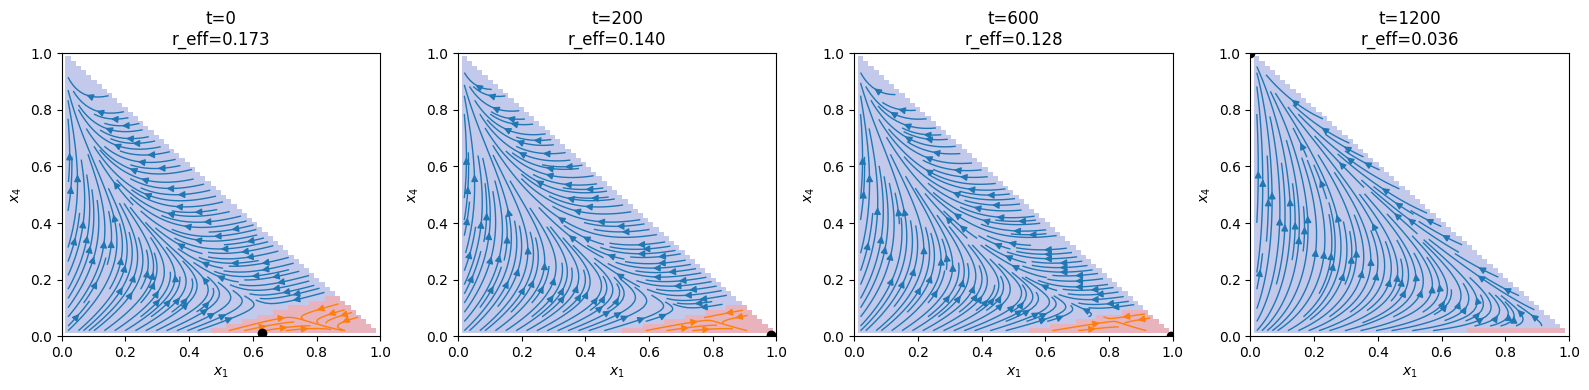

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ---------- Core dynamics ----------

def fitness_weights(s=0.1):
    R0 = 1 - s/2
    return np.array([R0, R0*(1-s), R0*(1-s), R0*(1+s)])

def phase_step(x, r, w):
    w_bar = x @ w
    D = (w[0]*w[3]*x[0]*x[3] - w[1]*w[2]*x[1]*x[2]) / w_bar**2
    x_next = np.empty_like(x)
    for i in range(4):
        sgn = -1 if i in [0,3] else 1
        x_next[i] = x[i]*w[i]/w_bar + sgn * r * D
    return x_next

def full_step(x, y, params):
    w = params["w"]
    r11, r22, r12, r = params["r11"], params["r22"], params["r12"], params["r"]

    w_bar = x @ w + y @ w
    x, y = x*w/w_bar, y*w/w_bar

    def update(a, b, r_self):
        out = np.zeros(4)
        for i in range(4):
            il = (i + 2) % 4
            ia = i - 1 if i % 2 else i + 1

            sgn_wtn = 1 if i in [0,3] else -1
            wtn = sgn_wtn * r_self * (a[0]*a[3] - a[1]*a[2])

            i1, i2 = min(i, il), max(i, il)
            sgn_btwn = -1 if i in [2,3] else 1
            btwn = sgn_btwn * r12 * (a[i1]*(b[2]+b[3]) - a[i2]*(b[0]+b[1]))

            bm = r * (a[i]*(b.sum()-b[i]) - b[i]*(a.sum()-a[i]))

            dbl = r*r12*(2*a[i]*b[il] - 2*a[il]*b[i]
                         + a[i]*b[3-i] + a[ia]*b[3-ia]
                         - a[3-i]*b[i] - a[3-ia]*b[ia])

            out[i] = a[i] - wtn - btwn - bm + dbl
        return out

    x_p = update(x, y, r11)
    y_p = update(y, x, r22)

    total = x_p.sum() + y_p.sum()
    return x_p/total, y_p/total

# ---------- Simulation ----------

def simulate(x0, y0, params, T=2000):
    traj = np.zeros((T, 8))
    reffs = np.zeros(T)

    x, y = x0.copy(), y0.copy()

    for t in range(T):
        traj[t] = np.concatenate([x, y])

        um1, um2 = x.sum(), y.sum()
        reffs[t] = params["r11"]*um1**2 + 2*params["r12"]*um1*um2 + params["r22"]*um2**2

        x, y = full_step(x, y, params)

    return traj, reffs

# ---------- Phase plane ----------

def make_phase_plane(r, w, n=60, steps=80):
    grid = np.linspace(0.02, 0.98, n)
    x1g, x4g = np.meshgrid(grid, grid)
    mask = (x1g + x4g) <= 1

    dx1 = np.zeros_like(x1g)
    dx4 = np.zeros_like(x4g)
    finals = []

    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            x1, x4 = x1g[i,j], x4g[i,j]
            x2 = x3 = (1 - x1 - x4)/2
            x = np.array([x1,x2,x3,x4])

            # local vector field
            xp = phase_step(x, r, w)
            dx1[i,j], dx4[i,j] = xp[0]-x1, xp[3]-x4

            # endpoint for clustering
            for _ in range(steps):
                x = phase_step(x, r, w)
            finals.append([x[0], x[3]])

    kmeans = KMeans(n_clusters=2, n_init=5, random_state=0).fit(finals)

    labels = np.full_like(x1g, np.nan)
    idx = 0
    for i in range(n):
        for j in range(n):
            if not mask[i,j]: continue
            labels[i,j] = kmeans.labels_[idx]
            idx += 1

    return x1g, x4g, dx1, dx4, labels

# ---------- Visualization ----------

def plot_snapshots(traj, reffs, params, times):
    w = params["w"]
    fig, axes = plt.subplots(1, len(times), figsize=(4*len(times),4))

    for ax, t in zip(axes, times):
        r = reffs[t]

        x1g, x4g, dx1, dx4, labels = make_phase_plane(r, w)

        ax.pcolormesh(x1g, x4g, labels, cmap="coolwarm", shading="auto", alpha=0.3)

        for lab in [0,1]:
            mask = (labels == lab)
            ax.streamplot(
                x1g, x4g,
                np.ma.masked_where(~mask, dx1),
                np.ma.masked_where(~mask, dx4),
                density=2, linewidth=1
            )

        # project trajectory point (x+y)
        xt = traj[t,:4] + traj[t,4:]
        ax.plot(xt[0], xt[3], 'ko', ms=6)

        ax.set_xlim(0,1); ax.set_ylim(0,1)
        ax.set_title(f"t={t}\nr_eff={r:.3f}")
        ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_4$")

    plt.tight_layout()
    plt.show()

# ---------- Run ----------

params = dict(
    w=fitness_weights(),
    r11=0.01,
    r22=0.336667,
    r12=0.173333,
    r=0.1
)

x_init = np.array([0.314474, 0.090263, 0.090263, 0.005])
y_init = x_init.copy()
norm = x_init.sum() + y_init.sum()
x_init /= norm; y_init /= norm

traj, reffs = simulate(x_init, y_init, params, T=1500)

times = [0, 200, 600, 1200]
plot_snapshots(traj, reffs, params, times)